# Data preparation and filtering of original dataset to use for the Neural Network

Transparency is important so I'm showing all my steps for the data preparation. The original dataset with images is too large to include in the GitHub, so you need to download it yourself. Make sure you store it somewhere where you can access it via a path.


In [1]:
import pandas as pd
from pathlib import Path
import json 
import numpy as np
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2

# check for model running: 
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

C:\Users\mulle\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.7.1+cu118
11.8
True
NVIDIA GeForce RTX 3070 Ti Laptop GPU


C:\Users\mulle\AppData\Roaming\Python\Python311\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [WinError 10054] An existing connection was forcibly closed by the remote host>
  data = fetch_version_info()


In [2]:
# -- IMPORTING ALL NON-IMAGE DATA -- #
# ground truth segmentations per img
seg = pd.read_csv("Radiology_hand_drawn_segmentations_v2.csv")
# anottations per img
annot = pd.read_excel("Radiology-manual-annotations.xlsx")

# The segmentation is sorted by the column called #filename. Annot is sorted by the column Image_name
# The only difference about these two is that #filename has .jpg after each entry. 
# So i'm removing that 

seg["#filename"] = seg["#filename"].str.replace(".jpg", "")

# Analysing values in seg:
# Using print(seg['COLUMNNAME'].unique()) I figured out that the columns region_attributes and file_attributes only contain {}. 
# I also don't think that the column "file_size" will be of any use. We can always change this if one of them is needed later.
seg = seg.drop(columns = ["file_attributes", "region_attributes", "file_size"])

# -- IMPORTING IMAGE DATA -- #
# Make sure you have the images dataset folder downloaded and saved in program files.
# Or change the path stuff around. 

# Due to python tweaking if you put in the raw path files with \, 
# put r in front of the string to treat it as raw string
imgs_locations = [Path(r"C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\Subtracted images of CDD-CESM")]

print(seg)
print(annot)
print(imgs_locations)
rows = []
for folder in imgs_locations:
    for img in folder.glob("*.jpg"):  # only get images and not the desktop.ini file
        rows.append({"image_id": img.stem, "image_path": str(img)})
images_df = pd.DataFrame(rows)

# Time for the full dataset? Yeahhh
dataset = (images_df
           .merge(annot, left_on = "image_id", right_on = "Image_name", how = "left")
           .merge(seg, left_on = "image_id", right_on = "#filename", how = "left"))

dataset["patient_id"] = dataset["image_id"].str.extract(r"(P\d+)")
dataset = dataset.drop(columns = ["Patient_ID", "Image_name"])
dataset


          #filename  region_count  region_id  \
0       P1_L_CM_MLO             1          0   
1       P1_L_DM_MLO             1          0   
2        P2_L_CM_CC             1          0   
3       P2_L_CM_MLO             1          0   
4        P2_L_DM_CC             4          0   
...             ...           ...        ...   
2966  P326_L_CM_MLO             1          0   
2967   P326_L_DM_CC             1          0   
2968  P326_L_DM_MLO             1          0   
2969   P326_R_DM_CC             1          0   
2970  P326_R_DM_MLO             1          0   

                                region_shape_attributes  
0     {"name":"polygon","all_points_x":[350,423,1005...  
1     {"name":"polygon","all_points_x":[353,413,1033...  
2     {"name":"polygon","all_points_x":[550,533,412,...  
3     {"name":"polygon","all_points_x":[26,954,945,8...  
4     {"name":"polygon","all_points_x":[4,107,349,49...  
...                                                 ...  
2966  {"name":"po

,image_id,image_path,Side,Type,Age,Breast density (ACR),BIRADS,Findings,View,Tags,Machine,Pathology Classification/ Follow up,#filename,region_count,region_id,region_shape_attributes,patient_id
0,P100_L_CM_CC,C:\Users\mulle\models_machine_learning\CLEANED...,L,CESM,61.0,_,2,Non enhancement,CC,postoperative,1.0,Benign,P100_L_CM_CC,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[187,258,202,...",P100
1,P100_L_CM_MLO,C:\Users\mulle\models_machine_learning\CLEANED...,L,CESM,61.0,_,2,Non enhancement,MLO,postoperative,1.0,Benign,P100_L_CM_MLO,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[138,326,494,...",P100
2,P100_R_CM_CC,C:\Users\mulle\models_machine_learning\CLEANED...,R,CESM,61.0,_,1,No mass or non mass enhancement,CC,normal,1.0,Normal,NaN,NaN,NaN,NaN,P100
3,P100_R_CM_MLO,C:\Users\mulle\models_machine_learning\CLEANED...,R,CESM,61.0,_,1,No mass or non mass enhancement,MLO,normal,1.0,Normal,NaN,NaN,NaN,NaN,P100
4,P101_L_CM_CC,C:\Users\mulle\models_machine_learning\CLEANED...,L,CESM,47.0,_,1,No mass or non mass enhancement,CC,normal,1.0,Normal,NaN,NaN,NaN,NaN,P101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,P99_L_CM_MLO,C:\Users\mulle\models_machine_learning\CLEANED...,L,CESM,61.0,_,1,No mass or non mass enhancement,MLO,normal,1.0,Normal,NaN,NaN,NaN,NaN,P99
1597,P99_L_CM_MLO_2,C:\Users\mulle\models_machine_learning\CLEANED...,L,CESM,61.0,_,1,No mass or non mass enhancement,MLO,normal,1.0,Normal,NaN,NaN,NaN,NaN,P99
1598,P99_R_CM_CC,C:\Users\mulle\models_machine_learning\CLEANED...,R,CESM,61.0,_,5,Heterogenously enhancing mass with irregular m...,CC,"malignant mass, heterogenous, irregular",1.0,Malignant,P99_R_CM_CC,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[2376,2326,22...",P99
1599,P99_R_CM_MLO,C:\Users\mulle\models_machine_learning\CLEANED...,R,CESM,61.0,_,5,Heterogenously enhancing mass with irregular m...,MLO,"malignant mass, heterogenous, irregular",1.0,Malignant,P99_R_CM_MLO,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[1656,1693,17...",P99


In [10]:
# -- Mask time for ground truth -- #

def create_mask(image_path, annot):
    """
    Creates a binary mask based on region shape attributes for an image, to use as truth.
    """
    img = np.array(Image.open(image_path))
    height, width = img.shape[:2]

    # mask should contain all 0's with 1 for identified tumors 
    mask = np.zeros((height, width), dtype=np.uint8) 

    for annotation in annot.dropna():
        shape = json.loads(annotation) # annotation is currently json so no more

        # -- We gotta keep the different shapes of annotations in mind! -- #
        # Seems like polygon, ellipse and circle are the ones used.
        shape_type = shape.get("name")

        if shape_type == "polygon":
            points = np.array(
                list(zip(shape["all_points_x"], shape["all_points_y"])),dtype=np.int32)
            cv2.fillPoly(mask, [points], 1)  # cv fillpoly is made for the polys

        elif shape_type == "circle":
            cv2.circle(mask,
                (shape["cx"], shape["cy"]), shape["r"],1, -1) # we can change color & thickness to outlines only, but i dont think we should

        elif shape_type == "ellipse":
            cv2.ellipse(
                mask,(shape["cx"], shape["cy"]),(shape["rx"], shape["ry"]), 0, 0,360, 1, -1)

    return mask

# -- Creating a new folder with all the masks per scan -- #

mask_folder = Path("masks_subtracted")
mask_folder.mkdir(exist_ok=True)
grouped = dataset.groupby("image_id")
for image_id, group in grouped:

    if group["region_shape_attributes"].isna().all():
        continue

    image_path = group["image_path"].iloc[0]
    mask = create_mask(image_path, group["region_shape_attributes"])

    cv2.imwrite(str(mask_folder / f"{image_id}_subtracted_mask.jpg"), mask * 255)


In [3]:
# To prevent errors later on during training, the images without masks need to be removed.
mask_folder = r"C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\masks_subtracted"

before = len(dataset["image_id"].unique())

valid_ids = []
for image_id in dataset["image_id"].unique():
    mask_path = Path(mask_folder) / f"{image_id}_subtracted_mask.jpg"
    if mask_path.exists():
        valid_ids.append(image_id)
    else:
        print(f"  Geen masker gevonden: {image_id}")

dataset = dataset[dataset["image_id"].isin(valid_ids)]

after = len(dataset["image_id"].unique())
print(f"\nVoor: {before} images | Na: {after} images | Verwijderd: {before - after}")

  Geen masker gevonden: P100_R_CM_CC
  Geen masker gevonden: P100_R_CM_MLO
  Geen masker gevonden: P101_L_CM_CC
  Geen masker gevonden: P101_L_CM_MLO
  Geen masker gevonden: P101_R_CM_CC
  Geen masker gevonden: P101_R_CM_MLO
  Geen masker gevonden: P102_L_CM_CC
  Geen masker gevonden: P102_L_CM_MLO
  Geen masker gevonden: P103_L_CM_CC
  Geen masker gevonden: P103_L_CM_MLO
  Geen masker gevonden: P104_R_CM_CC
  Geen masker gevonden: P105_L_CM_CC
  Geen masker gevonden: P105_L_CM_MLO
  Geen masker gevonden: P107_L_CM_CC
  Geen masker gevonden: P108_R_CM_CC
  Geen masker gevonden: P109_L_CM_CC
  Geen masker gevonden: P110_R_CM_CC
  Geen masker gevonden: P110_R_CM_MLO
  Geen masker gevonden: P111_L_CM_CC
  Geen masker gevonden: P111_L_CM_MLO
  Geen masker gevonden: P111_R_CM_CC
  Geen masker gevonden: P112_L_CM_CC
  Geen masker gevonden: P113_R_CM_MLO
  Geen masker gevonden: P114_L_CM_CC
  Geen masker gevonden: P114_L_CM_MLO
  Geen masker gevonden: P114_R_CM_CC
  Geen masker gevonden: P114

# Splitting
**Train** 70%

**Validation** 15%

**Test** 15%

In [4]:
patients = dataset["patient_id"].unique()
train_patients, test_patients = train_test_split(
    patients,
    test_size=0.10,   
    random_state=42,
    shuffle=True
)
#build dataframes (use dataset, not df)
df_trainval = dataset[dataset["patient_id"].isin(train_patients)]
# Don't touch this till the end
df_test = dataset[dataset["patient_id"].isin(test_patients)]
# safety check (so hopefully leakage)
assert set(df_trainval.patient_id).isdisjoint(set(df_test.patient_id))

#sizes
print("Train/Val:", len(df_trainval))
print("Test:", len(df_test))

Train/Val: 1028
Test: 140


# The UNet

Here is the UNet itself, along with the DiceLoss and the Dataset BreastDataset. There are also additional transform functions to increase the variation and difficulty of images, as we noticed that the model would make overly complex predictions a lot of the time, even when the tumor was very simple, or it would recognize things that are maybe there, but not even visible to us. And since there are not that many Patients, but mostly different variations of images per patient, we thought to expand the image variety even more. 

In [12]:
transform = A.Compose([
    A.Resize(512, 512),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        translate_percent=0.05,
        scale=(0.95, 1.05),
        rotate=(-10,10),
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.3
    ),
])

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        # Flatten each sample separately
        preds = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (preds * targets).sum(dim=1)

        dice = (2.0 * intersection + self.smooth) / (
            preds.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )

        return 1.0 - dice.mean()


class BreastDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        print(f"idx={idx}  image_id={row['image_id']}  path={row['image_path']}")
        img       = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        # I have no idea how else to do this properly but this'll do for now
        mask_path = mask_path = r"C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\masks_subtracted" + f"\\{row['image_id']}_subtracted_mask.jpg"
        mask      = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            raise ValueError(f"Missing image or mask for ID: {row['image_id']}")

       # Augmentatie eerst toepassen op de originele resolutie
        if self.augment:
            augmented = transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]
        else:
            img = cv2.resize(img, (512, 512))
            mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)


        img  = img.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)

        img  = np.expand_dims(img,  0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):

        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x5 = self.bottleneck(self.pool(x4))

        x = self.up4(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv4(x)

        x = self.up3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv1(x)

        return self.out(x)



# Don't use this one, the self-attention model doesn't really help. 

This is the SelfAttention Model. The core idea behind this model was that it would be allow the model to calculate which parts of the input are relevant to each other, and thus help reduce noise in the predictions of the UNet. This was overly complex and cost a lot of time, it may not even really work properly, but that does not matter too much as it showed no improvements at all. It also used up too much Memory, which meant that Self Attention could only be run on the deepest and smallest layer of the UNet. 

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim, dropout_prob=0.3):  # ← Dropout toegevoegd
        super(SelfAttention, self).__init__()
        self.query_conv = nn.Conv2d(in_channels=in_dim, out_channels=max(1, in_dim // 8), kernel_size=1)
        self.key_conv   = nn.Conv2d(in_channels=in_dim, out_channels=max(1, in_dim // 8), kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels=in_dim, out_channels=in_dim, kernel_size=1)
        self.gamma      = nn.Parameter(torch.zeros(1))
        
        # Voorkomt dat de attention map gaat overfitten op specifieke feature locaties
        self.attn_dropout = nn.Dropout2d(p=dropout_prob)

    def forward(self, x):
        m_batchsize, C, width, height = x.size()
        proj_query = self.query_conv(x).view(m_batchsize, -1, width * height).permute(0, 2, 1)
        proj_key   = self.key_conv(x).view(m_batchsize, -1, width * height)
        energy     = torch.bmm(proj_query, proj_key)
        attention  = torch.softmax(energy, dim=-1)
        
        proj_value = self.value_conv(x).view(m_batchsize, -1, width * height)

        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(m_batchsize, C, width, height)
        
        # Pas dropout toe op de berekende attention output vóór de residual optelling
        out = self.attn_dropout(out)
        
        out = self.gamma * out + x
        return out


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up   = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1    = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1    = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                            diffY // 2, diffY - diffY // 2])
        x     = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class Network(nn.Module):
    def __init__(self, n_channels, n_classes, middle_layers="64,128,256,512,1024", bilinear=False):
        print(middle_layers)
        try:
            middle_layers = np.array(middle_layers.split(",")).astype(int)
        except:
            raise ValueError("Expected 'middle_layers' to be comma-delimited list of integers like '64,128,256,512,1024'")
        if len(middle_layers) != 5:
            raise ValueError("middle_layers must be a list of length 5")

        super(Network, self).__init__()
        self.n_channels    = int(n_channels)
        self.middle_layers = middle_layers
        self.n_classes     = int(n_classes)
        self.bilinear      = bilinear

        self.inc   = DoubleConv(n_channels, middle_layers[0])
        self.down1 = Down(middle_layers[0], middle_layers[1])
        self.down2 = Down(middle_layers[1], middle_layers[2])
        self.down3 = Down(middle_layers[2], middle_layers[3])

        # Dropout toegevoegd aan de attention gate via de parameter (default=0.3)
        self.attention_4 = SelfAttention(middle_layers[3], dropout_prob=0.3)

        factor     = 2 if bilinear else 1
        self.down4 = Down(middle_layers[3], middle_layers[4] // factor)
        self.up1   = Up(middle_layers[4], middle_layers[3] // factor, bilinear)
        self.up2   = Up(middle_layers[3], middle_layers[2] // factor, bilinear)
        self.up3   = Up(middle_layers[2], middle_layers[1] // factor, bilinear)
        self.up4   = Up(middle_layers[1], middle_layers[0], bilinear)
        self.outc  = OutConv(middle_layers[0], n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        v1 = self.attention_4(x4)

        x = self.up1(x5, v1)
        x = self.up2(x,  x3)
        x = self.up3(x,  x2)
        x = self.up4(x,  x1)

        return self.outc(x)


## ORIGINAL

This is the original training and testing of the Fold version of the model. The training of the self attention model without folds, was lost somewhere along the way after it burned my GPU with 125 Epochs of nothing useful really. 

In [7]:
%%time
device = "cuda" if torch.cuda.is_available() else "cpu"

groups = df_trainval["patient_id"]
group_k_fold = GroupKFold(n_splits=5)
fold_scores = []
for fold, (train_idx, val_idx) in enumerate(group_k_fold.split(df_trainval, groups=groups)):
    torch.cuda.empty_cache()
    print(f"FOLD {fold+1}")
    train_df = df_trainval.iloc[train_idx]
    val_df   = df_trainval.iloc[val_idx]

    assert set(train_df.patient_id).isdisjoint(set(val_df.patient_id))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())

    # datata
    train_ds = BreastDataset(train_df)
    val_ds   = BreastDataset(val_df)

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=4)

    # model, new one per fold
    model = UNet(in_channels=1, out_channels=1).to(device)

    loss_fn = DiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val = float("inf")

    # Training

    for epoch in range(25):

        # TRAIN
        model.train()
        train_loss = 0

        for imgs, masks in train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)\
            
            optimizer.zero_grad()
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            torch.cuda.empty_cache() 
            
        # evalidated? I hope it works? 
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device)
                masks = masks.to(device)

                preds = model(imgs)
                loss = loss_fn(preds, masks)

                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f"unet_subtracted_fold_{fold+1}.pth")

    fold_scores.append(best_val)


FOLD 1
Train patients: 195
Val patients: 48
Epoch 1: Train=0.6721 | Val=0.7419
Epoch 2: Train=0.6362 | Val=0.7350
Epoch 3: Train=0.6149 | Val=0.6858
Epoch 4: Train=0.6002 | Val=0.9299
Epoch 5: Train=0.5994 | Val=0.6988
Epoch 6: Train=0.5617 | Val=0.6908
Epoch 7: Train=0.5534 | Val=0.6599
Epoch 8: Train=0.5433 | Val=0.6576
Epoch 9: Train=0.5408 | Val=0.7458
Epoch 10: Train=0.5281 | Val=0.6746
Epoch 11: Train=0.5236 | Val=0.6611
Epoch 12: Train=0.5183 | Val=0.6640
Epoch 13: Train=0.5166 | Val=0.6521
Epoch 14: Train=0.5058 | Val=0.6684
Epoch 15: Train=0.4994 | Val=0.6712
Epoch 16: Train=0.4995 | Val=0.6867
Epoch 17: Train=0.4803 | Val=0.7273
Epoch 18: Train=0.4901 | Val=0.6743
Epoch 19: Train=0.4756 | Val=0.6412
Epoch 20: Train=0.4659 | Val=0.6461
Epoch 21: Train=0.4522 | Val=0.6561
Epoch 22: Train=0.4505 | Val=0.6630
Epoch 23: Train=0.4466 | Val=0.6320
Epoch 24: Train=0.4489 | Val=0.6804
Epoch 25: Train=0.4197 | Val=0.6372
FOLD 2
Train patients: 195
Val patients: 48
Epoch 1: Train=0.7164

In [8]:
# Results? I think? 
print("CROSS VALIDATION RESULTS")

print("Fold scores:", fold_scores)
print("Mean:", np.mean(fold_scores))
print("Std:", np.std(fold_scores))

CROSS VALIDATION RESULTS
Fold scores: [0.6320320184414203, 0.560746438228167, 0.46740004420280457, 0.5475344130626092, 0.5378767870939695]
Mean: 0.5491179402057942
Std: 0.0525673890250828


In [9]:
# Testing all 5 folds using the plain UNet model
device = "cuda" if torch.cuda.is_available() else "cpu"

test_ds = BreastDataset(df_test)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

loss_fn = DiceLoss() 
test_scores = {}

# Loop through all 5 folds
for fold in range(1, 6): 
    model = UNet(in_channels=1, out_channels=1).to(device)
    
    model.load_state_dict(torch.load(f"unet_subtracted_fold_{fold}.pth", map_location=device))
    model.eval()

    test_loss = 0.0
    y_true = []
    y_pred = []

    print(f"Testing fold {fold}...")

    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            test_loss += loss.item()

            # Binarize output predictions at a threshold of 0.5
            the_preds = (torch.sigmoid(preds) > 0.5).float()
            
            # Flatten to calculate global pixel-level metrics across the test dataset
            y_pred.extend(the_preds.cpu().numpy().flatten())
            y_true.extend(masks.cpu().numpy().flatten())

    test_loss /= len(test_loader)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    iou = jaccard_score(y_true, y_pred, zero_division=0)
 
    test_scores[fold] = {
        "loss": test_loss, 
        "accuracy": accuracy, 
        "precision": prec, 
        "recall": rec, 
        "f1": f1, 
        "IoU": iou
    }
    
    print(
        f"Fold {fold}: "
        f"Loss={test_loss:.5f}, "
        f"Accuracy={accuracy:.5f}, "
        f"Precision={prec:.5f}, "
        f"Recall={rec:.5f}, "
        f"F1={f1:.5f}, "
        f"IoU={iou:.5f}\n"
    )

print("--- FINAL TEST SET RESULTS ---")
for fold, metrics in test_scores.items():
    print(f"Fold {fold}: {metrics}")

# Determine the best performing fold model by minimum test loss
best_fold = min(test_scores, key=lambda x: test_scores[x]["loss"])

print(f"\nBest fold on test set: Fold {best_fold}")
print(f'Minimum Test loss: {test_scores[best_fold]["loss"]:.4f}')
print(f'Best Fold Recall: {test_scores[best_fold]["recall"]:.4f}')

Testing fold 1...
Fold 1: Loss=0.51576, Accuracy=0.91164, Precision=0.70065, Recall=0.52758, F1=0.60192, IoU=0.43054

Testing fold 2...
Fold 2: Loss=0.51058, Accuracy=0.91346, Precision=0.75873, Recall=0.46418, F1=0.57598, IoU=0.40448

Testing fold 3...
Fold 3: Loss=0.52183, Accuracy=0.90342, Precision=0.63624, Recall=0.55405, F1=0.59231, IoU=0.42077

Testing fold 4...
Fold 4: Loss=0.54894, Accuracy=0.90116, Precision=0.65953, Recall=0.45357, F1=0.53749, IoU=0.36751

Testing fold 5...
Fold 5: Loss=0.50009, Accuracy=0.90951, Precision=0.68518, Recall=0.52790, F1=0.59635, IoU=0.42485

--- FINAL TEST SET RESULTS ---
Fold 1: {'loss': 0.5157568199293954, 'accuracy': 0.9116403034755162, 'precision': 0.7006505565053078, 'recall': 0.5275813739998721, 'f1': 0.601922444961687, 'IoU': 0.4305358045356732}
Fold 2: {'loss': 0.5105818016188485, 'accuracy': 0.9134637832641601, 'precision': 0.7587294987977505, 'recall': 0.46418261466299665, 'f1': 0.5759842243727833, 'IoU': 0.4044788226584691}
Fold 3: {

The testing has always been hit or miss, as many versions of the models have been trained. Many have also been lost or retrained. The most important score to us is Recall, and even though the recall here is low, the Model seems to find a lot of Tumors, so perhaps there is a mismatch with what the recall_score function considers good and not good? The Recall has varied between a low of 0.40 on the worst models to 0.80 on the best models way back at the start of the project. 

# Visualizing

This is to give a visualization of the models predictions on the test set. There is another code block underneath it, there you can specifically check a single file and image, regardless of it being in the test or training set. 

Showing test image index: 108 using weights from Best Fold (5)


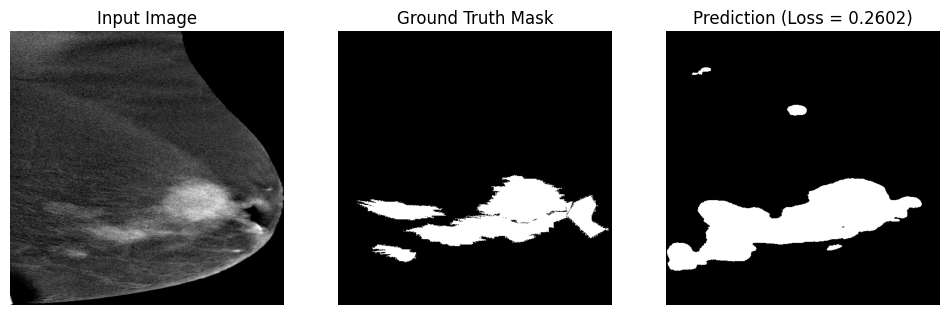

In [11]:
# Visualisation of the model
idx = np.random.choice(len(test_ds))
print(f"Showing test image index: {idx} using weights from Best Fold ({best_fold})")
img, mask = test_ds[idx]
best_model = UNet(in_channels=1, out_channels=1).to(device)

best_model.load_state_dict(torch.load(f"unet_subtracted_fold_{best_fold}.pth", map_location=device))
best_model.eval()

with torch.no_grad():
    logits = best_model(img.unsqueeze(0).to(device))
    dice_loss = loss_fn(logits, mask.unsqueeze(0).to(device)).item()

    pred = torch.sigmoid(logits)
    pred = (pred > 0.5).float()

img = img.squeeze().cpu()
mask = mask.squeeze().cpu()
pred = pred.squeeze().cpu()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(r"Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title(f"Prediction (Loss = {dice_loss:.4f})")
plt.axis("off")

plt.show()

Found 'P99_R_CM_MLO' inside the Training/Validation split.


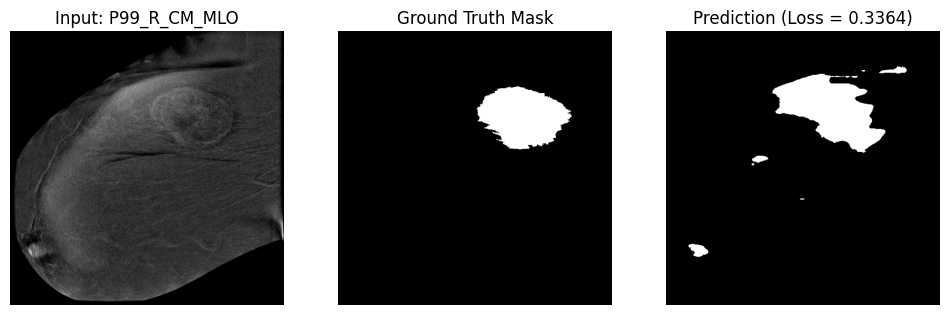

Saved raw predicted mask to: P99_R_CM_MLO_predicted_mask_fold5.png


In [20]:
# 1. Target image name (your script trims the extension into image_id)
target_img_name = "P99_R_CM_MLO"
# define names for saving
plot_filename = f"{target_img_name}_comparison_fold5.png"
mask_filename = f"{target_img_name}_predicted_mask_fold5.png"

if "df_test" in globals() and df_test['image_id'].str.contains(target_img_name, case=False).any():
    print(f"Found '{target_img_name}' in your test dataset split.")
    matched_row = df_test[df_test['image_id'].str.contains(target_img_name, case=False)]

elif "df_trainval" in globals() and df_trainval['image_id'].str.contains(target_img_name, case=False).any():
    print(f"Found '{target_img_name}' inside the Training/Validation split.")
    matched_row = df_trainval[df_trainval['image_id'].str.contains(target_img_name, case=False)]

elif "dataset" in globals() and dataset['image_id'].str.contains(target_img_name, case=False).any():
    print(f"Found '{target_img_name}' somewhere in the master dataset.")
    matched_row = dataset[dataset['image_id'].str.contains(target_img_name, case=False)]

else:
    raise ValueError(f"Could not find '{target_img_name}' anywhere. Check if the image was removed.")

eval_ds = BreastDataset(matched_row.head(1), augment=False)
img, mask = eval_ds[0]

# Setup model and perform evaluation
best_model = UNet(in_channels=1, out_channels=1).to(device)
best_model.load_state_dict(torch.load(f"unet_subtracted_fold_5.pth", map_location=device))
best_model.eval()

with torch.no_grad():
    logits = best_model(img.unsqueeze(0).to(device))
    dice_loss = loss_fn(logits, mask.unsqueeze(0).to(device)).item()

    pred = torch.sigmoid(logits)
    pred = (pred > 0.5).float()

# Move tensors back to CPU for standard plotting
img = img.squeeze().cpu()
mask = mask.squeeze().cpu()
pred = pred.squeeze().cpu()

# Display
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Input: {target_img_name}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title(f"Prediction (Loss = {dice_loss:.4f})")
plt.axis("off")

plt.show()

mask_to_save = (pred.numpy() * 255).astype(np.uint8)
cv2.imwrite(mask_filename, mask_to_save)
print(f"Saved raw predicted mask to: {mask_filename}")

## TEST FOR WITHOUT FOLD

A seperate block for testing without folds, as this was often done using the Attention model. 

In [8]:
%%time
device = "cuda" if torch.cuda.is_available() else "cpu"
train_patients, val_patients = train_test_split(
    df_trainval["patient_id"].unique(),
    test_size=0.1,
    random_state=42,
    shuffle=True
)

train_df = df_trainval[df_trainval["patient_id"].isin(train_patients)]
val_df   = df_trainval[df_trainval["patient_id"].isin(val_patients)]

assert set(train_df.patient_id).isdisjoint(set(val_df.patient_id))

print("Train:", len(train_df), "rows |", train_df["patient_id"].nunique(), "patients")
print("Val:  ", len(val_df),   "rows |", val_df["patient_id"].nunique(),   "patients")

train_ds = BreastDataset(train_df, augment=True)
val_ds   = BreastDataset(val_df,   augment=False)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=2)

model     = Network(n_channels=1, n_classes=1).to(device)
loss = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

best_val = float("inf")

for epoch in range(25):

    # TRAIN
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        del imgs, masks, preds, loss
        torch.cuda.empty_cache()

    # VALIDATIE
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss  = loss_fn(preds, masks)
            val_loss += loss.item()
            del imgs, masks, preds, loss

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    scheduler.step(val_loss)  # na elke epoch
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f} | LR={current_lr:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "attention_unet_best.pth")
        print(f"Beste model opgeslagen (val={best_val:.4f})")

print(f"\nTraining finished. Beste val loss: {best_val:.4f}")

Train: 925 rows | 218 patients
Val:   103 rows | 25 patients
CPU times: total: 15.6 ms
Wall time: 3.19 ms


NameError: name 'Network' is not defined

# Creating the Predictions used for the Prototype

Here the prediction masks are created for the prototype. We use the best trained model to do so, but this model isn't included in the Github due to the storage constraints. There are a few parameters that can be adjusted, and 4, or 5 if you want a 'heatmap' version of the mask, are exported to a folder. 
The exports are: the image itself, the predicted mask, contour overlays of the prediction and the original, and the 

In [18]:

# PARAMETERS

TOP_N         = 25          
THRESHOLD     = 0.5            
OUTPUT_DIR    = Path("prototype_exports")   # Where your top 25 results will be saved

# CHANGE THIS to the exact folder path where your Human Radiologist Masks are
RADIOLOGIST_MASK_DIR = Path(r"C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\masks_subtracted") 

# CHANGE THIS to match how your human radiologist files are named on disk:
# (e.g., if it's "P149_R_CM_MLO.png", change this to "{image_id}.png")
MASK_FILE_FORMAT = "{image_id}_subtracted_mask.jpg"

OUTPUT_DIR.mkdir(exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"


# Load the model that is trained.

eval_model = UNet(in_channels=1, out_channels=1).to(device)
eval_model.load_state_dict(
    torch.load("unet_subtracted_fold_5.pth", map_location=device)
)
model_label = "fold_5"

eval_model.eval() # Disables dropout/batchnorm updates
loss_fn_eval = DiceLoss()

# Drop duplicates to prevent the patient name misalignment bug
df_test_unique = df_test.drop_duplicates(subset="image_id").reset_index(drop=True)
test_ds_export = BreastDataset(df_test_unique, augment=False)

print("Busy generating live predictions…")
results = []   

# torch.no_grad() deactivates weight updates and tracking
with torch.no_grad():
    for idx in range(len(test_ds_export)):
        # Get the image from the dataset pipeline (ignore the pipeline's mask)
        img_t, _ = test_ds_export[idx]          
        img_np = img_t.squeeze().numpy() 
        
        # Get the correct, matching image_id
        image_id = df_test_unique.iloc[idx]["image_id"]

        # Load the Human Radiologist Mask from your specified directory
        mask_name = MASK_FILE_FORMAT.format(image_id=image_id)
        rad_mask_path = RADIOLOGIST_MASK_DIR / mask_name

        if not rad_mask_path.exists():
            print(f"Radiologist mask not found for {image_id} at {rad_mask_path}. Skipping.")
            continue
            
        rad_img = cv2.imread(str(rad_mask_path), cv2.IMREAD_GRAYSCALE)
        if rad_img is None:
            print(f"Could not read mask file for {image_id}. Skipping.")
            continue
            
        # Dynamically match the Radiologist mask size to the dataset image size (512x512)
        h, w = img_np.shape
        rad_img_resized = cv2.resize(rad_img, (w, h), interpolation=cv2.INTER_NEAREST)
        gt_np = (rad_img_resized > 0).astype(np.float32)

        # Convert the loaded radiologist mask into a PyTorch tensor for validation math
        mask_in = torch.from_numpy(gt_np).unsqueeze(0).unsqueeze(0).to(device) 
        img_in  = img_t.unsqueeze(0).to(device)                               

        # Live inference without learning
        logits    = eval_model(img_in)
        dice_val  = loss_fn_eval(logits, mask_in).item()  # Loss calculation against Radiologist Mask

        pred_prob = torch.sigmoid(logits)
        pred_bin  = (pred_prob > THRESHOLD).float()

        # Calculate final Dice Score (1 minus loss)
        dice_score = 1.0 - dice_val

        results.append({
            "image_id":   image_id,
            "dice_loss":  dice_val,
            "dice_score": dice_score,
            "img":        img_np,       
            "mask":       gt_np,                                # Human Radiologist Mask
            "pred":       pred_bin.squeeze().cpu().numpy(),     # Model's Live Prediction
            "pred_prob":  pred_prob.squeeze().cpu().numpy(),   
        })
        print(f"  [{idx+1}/{len(test_ds_export)}] {image_id}  Dice Score={dice_score:.4f} (Loss={dice_val:.4f})")


# Sort and Export top predictions
results.sort(key=lambda x: x["dice_score"], reverse=True)

print(f"\nTop {TOP_N} best live predictions based on Radiologist evaluation:")
for r in results[:TOP_N]:
    print(f"  {r['image_id']:40s}  Dice={r['dice_score']:.4f}  Loss={r['dice_loss']:.4f}")

print(f"\nExporting to '{OUTPUT_DIR}/'…")
for rank, r in enumerate(results[:TOP_N], start=1):
    img_id = r["image_id"]
    score  = r["dice_score"]
    prefix = f"rank{rank:02d}_{img_id}_dice{score:.4f}_{model_label}"

    # Export images
    img_8u = (r["img"] * 255).astype(np.uint8)
    cv2.imwrite(str(OUTPUT_DIR / f"{prefix}_image.png"), img_8u)
    
    gt_8u = (r["mask"] * 255).astype(np.uint8)
    cv2.imwrite(str(OUTPUT_DIR / f"{prefix}_gt_mask.png"), gt_8u)
    
    pred_8u = (r["pred"] * 255).astype(np.uint8)
    cv2.imwrite(str(OUTPUT_DIR / f"{prefix}_pred_mask.png"), pred_8u)

    # Generate Contour Overlay
    overlay_rgb = cv2.cvtColor(img_8u, cv2.COLOR_GRAY2BGR)
    gt_contours, _   = cv2.findContours(gt_8u,   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pred_contours, _ = cv2.findContours(pred_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cv2.drawContours(overlay_rgb, gt_contours,   -1, (0, 255, 0), 2)   # Green = Human Radiologist
    cv2.drawContours(overlay_rgb, pred_contours, -1, (0, 0, 255), 2)   # Red = Live Model Prediction
    cv2.imwrite(str(OUTPUT_DIR / f"{prefix}_overlay.png"), overlay_rgb)

    # Save 4-Panel Summary Graphic
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"Rank {rank} | {img_id} | Dice={score:.4f}", fontsize=12)

    axes[0].imshow(r["img"],  cmap="gray"); axes[0].set_title("Subtracted mammogram"); axes[0].axis("off")
    axes[1].imshow(r["mask"], cmap="gray"); axes[1].set_title("Radiologist Mask (GT)"); axes[1].axis("off")
    axes[2].imshow(r["pred"], cmap="gray"); axes[2].set_title("Model Prediction Live"); axes[2].axis("off")

    overlay_show = cv2.cvtColor(overlay_rgb, cv2.COLOR_BGR2RGB)
    axes[3].imshow(overlay_show); axes[3].set_title("Overlay (groen=GT, rood=pred)"); axes[3].axis("off")

    plt.tight_layout()
    fig.savefig(str(OUTPUT_DIR / f"{prefix}_summary.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)

# Save Leaderboard Spreadsheet
csv_path = OUTPUT_DIR / "ranking.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["rank", "image_id", "dice_score", "dice_loss"])
    writer.writeheader()
    for rank, r in enumerate(results, start=1):
        writer.writerow({
            "rank":       rank,
            "image_id":   r["image_id"],
            "dice_score": round(r["dice_score"], 6),
            "dice_loss":  round(r["dice_loss"],  6),
        })

print(f"\nDone! The top 25 best live predictions matching your radiologist files are in '{OUTPUT_DIR}/'")

Busy generating live predictions…
idx=0  image_id=P110_L_CM_MLO  path=C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\Subtracted images of CDD-CESM\P110_L_CM_MLO.jpg
  [1/56] P110_L_CM_MLO  Dice Score=0.2188 (Loss=0.7812)
idx=1  image_id=P125_L_CM_CC  path=C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\Subtracted images of CDD-CESM\P125_L_CM_CC.jpg
  [2/56] P125_L_CM_CC  Dice Score=0.0000 (Loss=1.0000)
idx=2  image_id=P125_L_CM_MLO  path=C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\Subtracted images of CDD-CESM\P125_L_CM_MLO.jpg
  [3/56] P125_L_CM_MLO  Dice Score=0.0000 (Loss=1.0000)
idx=3  image_id=P136_L_CM_MLO  path=C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\Subtracted images of CDD-CESM\P136_L_CM_MLO.jpg
  [4/56] P136_L_CM_MLO  Dice Score=0.5189 (Loss=0.4811)
idx=4  image_id=P149_L_CM_CC  path=C:\Users\mulle\models_machine_learning\CLEANED\CDD-CESM\Subtracted images of CDD-CESM\P149_L_CM_CC.jpg
  [5/56] P149_L_CM_CC  Dice Score=0.5062 (Loss=

	
## Data Citation
Khaled R., Helal M., Alfarghaly O., Mokhtar O., Elkorany A., El Kassas H., Fahmy A. Categorized Digital Database for Low energy and Subtracted Contrast Enhanced Spectral Mammography images [Dataset]. (2021) The Cancer Imaging Archive. DOI:  10.7937/29kw-ae92 

Khaled, R., Helal, M., Alfarghaly, O., Mokhtar, O., Elkorany, A., El Kassas, H., & Fahmy, A. Categorized contrast enhanced mammography dataset for diagnostic and artificial intelligence research. (2022) Scientific Data, Volume 9, Issue 1. DOI: 10.1038/s41597-022-01238-0

Clark K, Vendt B, Smith K, Freymann J, Kirby J, Koppel P, Moore S, Phillips S, Maffitt D, Pringle M, Tarbox L, Prior F. The Cancer Imaging Archive (TCIA): Maintaining and Operating a Public Information Repository, Journal of Digital Imaging, Volume 26, Number 6, December, 2013, pp 1045-1057. DOI: 10.1007/s10278-013-9622-7